# BalloonLib — Quick Start  

End-to-end demonstration of the **BalloonLib** PINN library:  
from numerical simulation of haemodynamics to PINN training and evaluation.

**Pipeline**
```
Stimulus → Numerical ODE (balloonmodellib)  →  reference f, m, v, q, BOLD
         → PINN (Multihead)                →  learned f, m, v, q, HRF
         → Evaluation (kge_stat, hrf_description)
         → [Optional] Noisy BOLD training
```

> **GPU recommended.** The library detects CUDA automatically.

## 0  Setup and imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
# ── BalloonLib (explicit submodule imports — preferred over balloonpinnlib shim)
from balloonlib import balloonmodellib as bml          # numerical ODE solver
from balloonlib.model    import Multihead
from balloonlib.training import loss, train
from balloonlib.data     import experimental_stims
from balloonlib.utils    import np2tensor, tensor2np, tofit, timeBall
from balloonlib.metrics  import kge_stat, hrf_description
from balloonlib.plotting import plot_balloon_fitting, plot_trace, plot_weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)
print(f'Using device: {device}')

Using device: cuda


## 1  Stimulus design

We use a block-design stimulus with 10 onsets at 1.75 s TR (166 volumes, ~4.8 min).

In [2]:
# ── fMRI acquisition parameters
TR        = 1.75          # Repetition time (s)
n_samples = 166           # number of fMRI volumes
Bold_time = np.arange(0, n_samples * TR, TR)

sti_len    = 3            # stimulus block duration (s)
Sti_Onsets = np.array([22, 42, 79, 99, 134, 163, 191, 209, 236, 269]) - 1  # onset times (s)

# ── High-res (0.01 s) impulse used by the PINN
Impulse = torch.zeros(30).repeat(100)  # 30 s at 100 Hz
Impulse[5:105] = 1                     # stimulus on from 0.05 s to 1.05 s

# ── Overall stimulus for BOLD convolution
Overall_stims, stim_time = experimental_stims(
    normDataSize = n_samples,
    Sti_Onsets   = Sti_Onsets,
    TR           = TR,
    block_len    = sti_len,
    stmxblck     = 1,
    Hz           = 100,
)
stim_time_np = tensor2np(stim_time)
print(f'Stimulus tensor shape: {Impulse.shape}  ({Impulse.shape[0]/100:.0f} s at 100 Hz)')
print(f'Overall stim shape:    {Overall_stims.shape}')

Stimulus tensor shape: torch.Size([3000])  (30 s at 100 Hz)
Overall stim shape:    torch.Size([29050, 1])


## 2  Numerical Balloon model (reference solution)

`balloonmodellib` solves the Balloon ODE system numerically (scipy).  
These solutions serve as ground-truth overlays when evaluating the PINN.

In [3]:
# ── Neurovascular coupling → f (CBF) and m (CMRO₂)
f_parameters = {'gamma': 1/2.46, 'kappa': 1/1.54}

f_np, _ = bml.NeurovascularCoupling(
    stimulus = tensor2np(Impulse), version='differential',
    params=f_parameters, AmpI=0.2,
)
m_np, _ = bml.NeurovascularCoupling(
    stimulus = tensor2np(Impulse), version='differential',
    params=f_parameters, AmpI=0.05,
)

# ── Balloon core → blood volume (v) and deoxyhaemoglobin (q)
vol_q_parameters = {'tau_MTT': 3.0, 'alpha': 0.4, 'tau_m': 20}
v_np, q_np = bml.Balloon_odeint(f_np, m_np, params=vol_q_parameters, viscoelastic=True)

# ── BOLD signal
bold_params = {'E_0': 0.32, 'V_0': 0.03, 'TE': 0.06, 'O_o': 40.3, 'r_0': 25, 'eps': 1.43}
bold_np     = bml.BOLD_func(v_np, q_np, params=bold_params, BM='classic')

# ── Convert to tensors
f_t = np2tensor(f_np)
m_t = np2tensor(m_np)
v_t = np2tensor(v_np)
q_t = np2tensor(q_np)
num_balloon_hrf = np2tensor(bold_np)

print(f'f shape: {f_t.shape} | m: {m_t.shape} | v: {v_t.shape} | q: {q_t.shape}')
print(f'Numerical HRF range: [{bold_np.min():.4f}, {bold_np.max():.4f}]')

f shape: torch.Size([3000, 1]) | m: torch.Size([3000, 1]) | v: torch.Size([3000, 1]) | q: torch.Size([3000, 1])
Numerical HRF range: [-0.0006, 0.0063]


## 3  Simulate BOLD signal (no noise)

Convolve the numerical HRF with the experimental stimulus to get a synthetic BOLD signal,  
then subsample it at the fMRI TR.

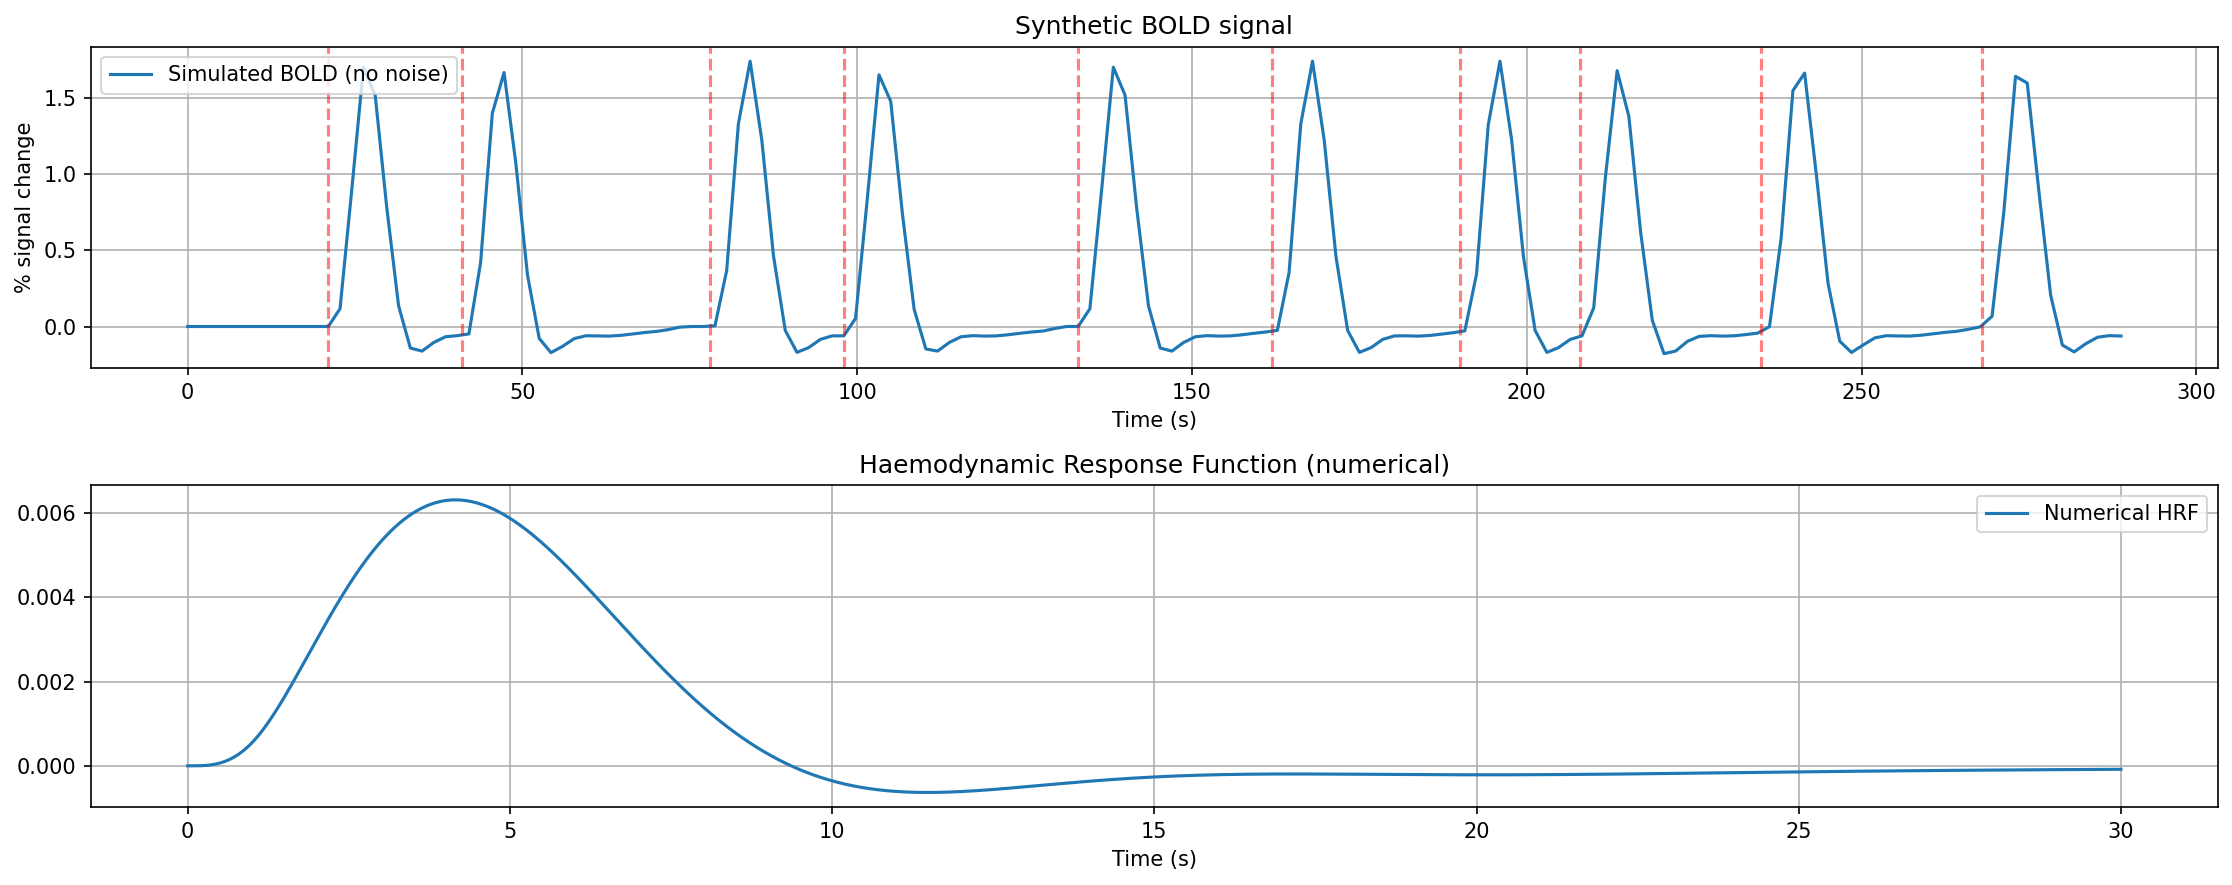

In [4]:
sampling_rate = int(TR * 100)   # samples to skip = TR × Hz

num_bold_test, num_bold_time = tofit(Overall_stims, num_balloon_hrf, n_samples * TR)
sampled_bold_test = tensor2np(num_bold_test[::sampling_rate])

fig, ax = plt.subplots(2, 1, figsize=(15, 6), dpi=150)
ax[0].plot(Bold_time, sampled_bold_test, label='Simulated BOLD (no noise)')
[ax[0].axvline(x=i, color='r', ls='--', alpha=0.5) for i in Sti_Onsets]
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('% signal change')
ax[0].set_title('Synthetic BOLD signal')
ax[0].legend()
ax[0].grid()

t_hrf = np.linspace(0, 30, len(bold_np))
ax[1].plot(t_hrf, bold_np, label='Numerical HRF')
ax[1].set_xlabel('Time (s)')
ax[1].set_title('Haemodynamic Response Function (numerical)')
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

## 4  Configure Balloon_params and data_params

`Balloon_params` — physiological ODE constants passed to `loss()` and `train()`.  
`data_params`   — fMRI data, stimulus metadata, and training settings.

In [5]:
domain     = (0, len(Impulse) * 0.01)   # physical time window: [0, 30] s
num_iter   = 5000
every      = num_iter // 3        # plot progress 3 times during training

learning_rate = 4e-3
percent, step_size = 0.85, 1000   # StepLR: lr × 0.85 every 1000 iters

# ── Initial loss weights  (lists — histories are appended during training)
p     = 0.6
w_raw = {
    'ode':    [p    ],   # ODE residual
    'bold':   [1 - p],   # data fit
    'ic':     [1.   ],   # Dirichlet IC  (f=m=v=q=1 at t=0)
    'border': [1.   ],   # Cauchy IC     (derivatives=0 at t=0)
    'other':  [0.   ],   # physics violation penalty (off by default)
}

# ── data_params
data_dict = {
    'TR':               TR,
    'Sti_Onsets':       Sti_Onsets,
    'Bold_Signal':      sampled_bold_test,   # numpy array, shape (n_samples,)
    'errorFn':          nn.MSELoss(),
    'stim_length [seg]': sti_len,            # block duration (s)
    'stim_x_block':     1,                  # stimuli per block
    't0':               0,                  # BOLD record start (s)
}

# ── Balloon_params  (physiological ODE constants from Stephan 2007 / Buxton 2004)
Balloon_dict = {
    'lambdar_list': [0.2, 0.05],      # [CBF amplitude, CMRO2 amplitude]
    'kappa_list':   [1/1.54, 1/1.54], # [CBF decay, CMRO2 decay]  (Maith 2022)
    'gamma_list':   [1/2.46, 1/2.46], # [CBF return, CMRO2 return]
    'tau_m_list':   20,               # viscoelastic time constant (s)
    'tau_MTT_list': 3.0,              # mean transit time (s)
    'alpha':        0.4,              # Grubb's stiffness exponent
    'I':            Impulse,               # high-res stimulus tensor
}

print('Balloon_dict keys:', list(Balloon_dict.keys()))
print('data_dict keys:',    list(data_dict.keys()))

Balloon_dict keys: ['lambdar_list', 'kappa_list', 'gamma_list', 'tau_m_list', 'tau_MTT_list', 'alpha', 'I']
data_dict keys: ['TR', 'Sti_Onsets', 'Bold_Signal', 'errorFn', 'stim_length [seg]', 'stim_x_block', 't0']


## 5  Build the PINN

`Multihead` simultaneously predicts all four Balloon state variables  
(*f*, *m*, *v*, *q*) from a normalised time input.

In [6]:
# ── Optional: fix random seed for reproducibility
# seed = 42
# torch.manual_seed(seed)
# if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

model = Multihead(
    use_fourier           = False,            # set True for Fourier feature encoding
    fourier_mapping_size  = 9,
    fourier_scale         = 0.85,
    fourier_learnable     = True,
    multi_scale_fourier   = False,
    random_weightsMatrix  = True,             # use FactorizedLinear (RWF) layers
    impulse               = False,            # time-only input
    act                   =  nn.Softmax(dim=1),
    nv_fn                 = (nn.Softplus(), nn.Softplus()),
    core_fn               = (nn.Softplus(), nn.Softplus()),
    dtype                 = torch.float32,
)
model.init_nn_params()

total_params = sum(p.numel() for p in model.parameters())
print(f'PINN ready: {total_params:,} trainable parameters | device: {next(model.parameters()).device}')

PINN ready: 165,896 trainable parameters | device: cuda:0


## 6  Train — clean (noise-free) simulation

The `train()` loop:
- Normalises time to zero-mean / unit-std
- Segments the BOLD data into stimulus-locked epochs
- Runs `num_iter` Adam steps with StepLR decay
- Plots progress every `every` iterations

 33%|███▎      | 1663/5000 [00:22<00:44, 75.64it/s]

1666th Iter:
total 1.5249e-03, ode:1.974e-03, bold:4.723e-04, Dic:8.283e-06, Cic:1.432e-04, other:4.069e-04
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1.0, 'bold': 1.0, 'ic': 1.0, 'border': 1.0, 'other': 1.0}


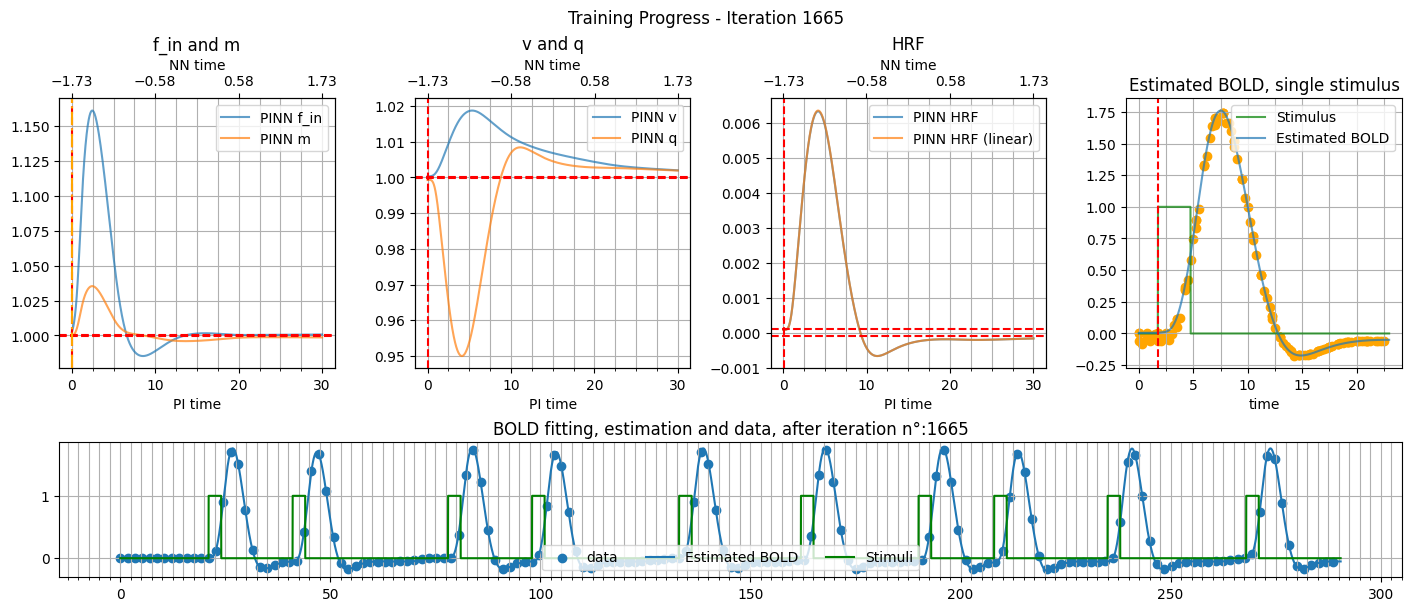

 67%|██████▋   | 3326/5000 [00:44<00:21, 76.83it/s]

3332th Iter:
total 1.4323e-03, ode:1.345e-03, bold:2.561e-04, Dic:1.870e-05, Cic:5.043e-04, other:5.869e-04
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1.0, 'bold': 1.0, 'ic': 1.0, 'border': 1.0, 'other': 1.0}


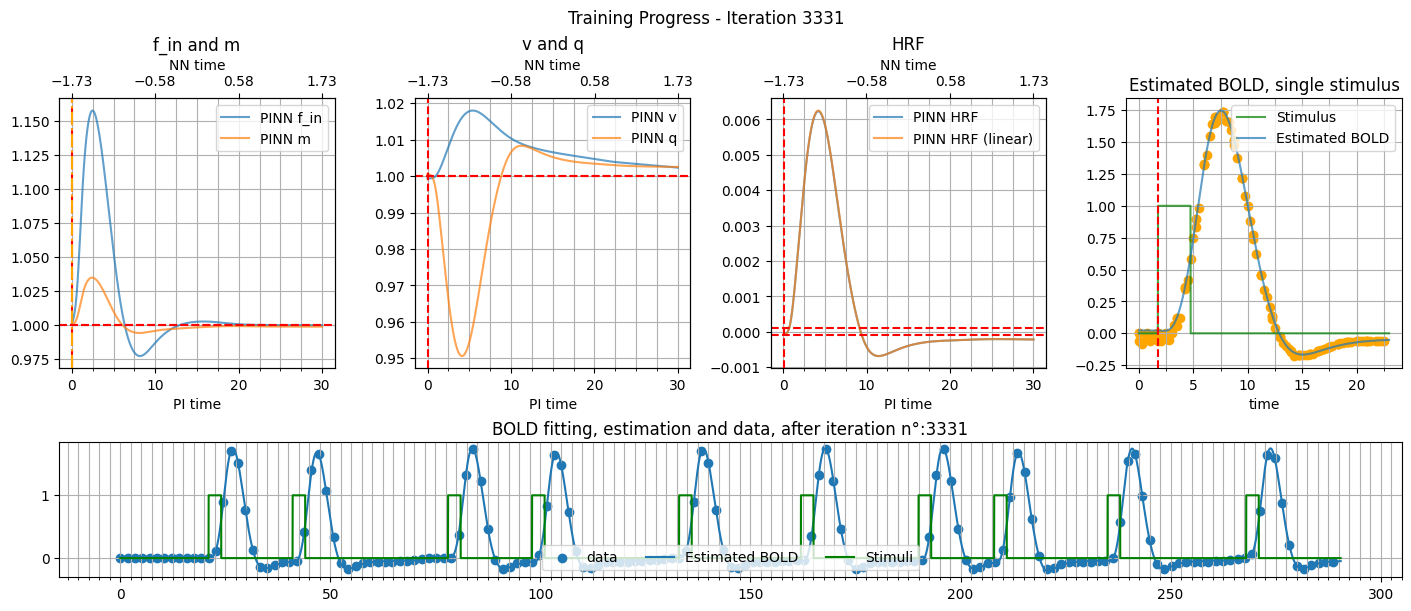

100%|█████████▉| 4991/5000 [01:06<00:00, 76.05it/s]

4998th Iter:
total 1.2599e-03, ode:1.473e-03, bold:1.528e-04, Dic:7.637e-06, Cic:3.073e-04, other:6.552e-04
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1.0, 'bold': 1.0, 'ic': 1.0, 'border': 1.0, 'other': 1.0}


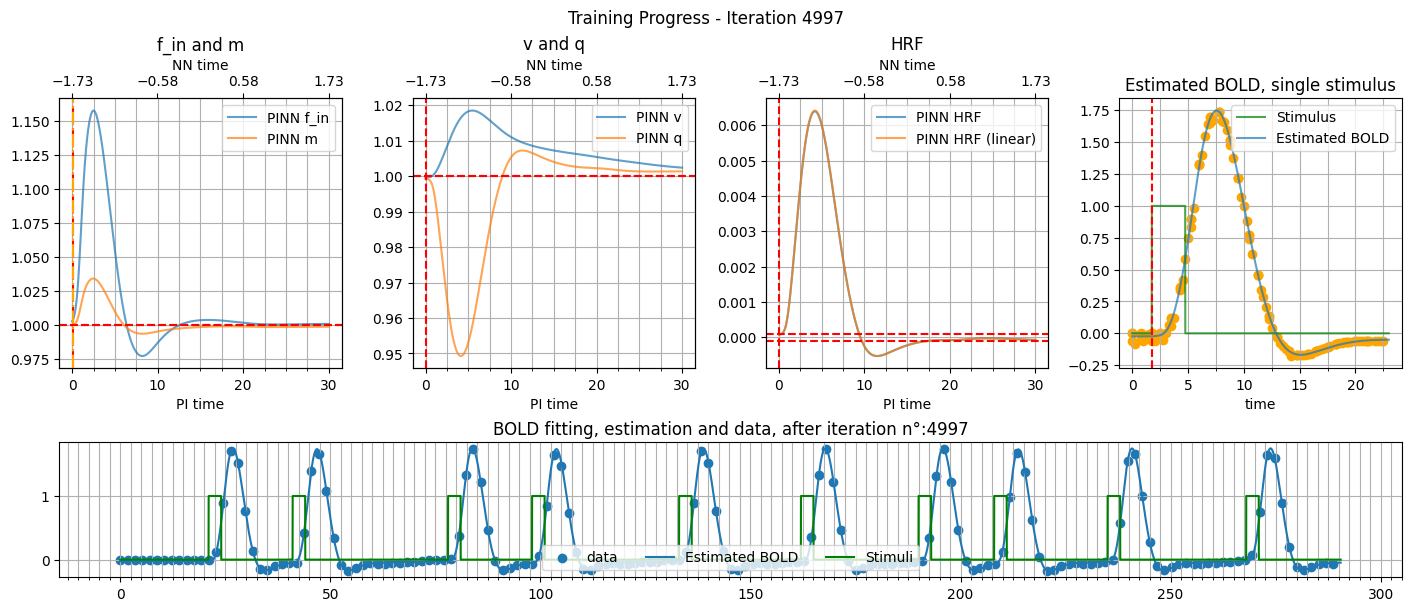

100%|██████████| 5000/5000 [01:07<00:00, 74.24it/s]


In [7]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=percent)

loss_trace = train(
    model          = model,
    optimizer      = optimizer,
    lossfn         = loss,
    num_iter       = num_iter,
    Balloon_params = Balloon_dict,
    data_params    = data_dict,
    domain         = domain,
    random         = False,
    every          = every,
    loss_weights   = w_raw,
    scheduler      = scheduler,
    dtype          = torch.float32,
)

## 7  Visualise — state variables + BOLD fit

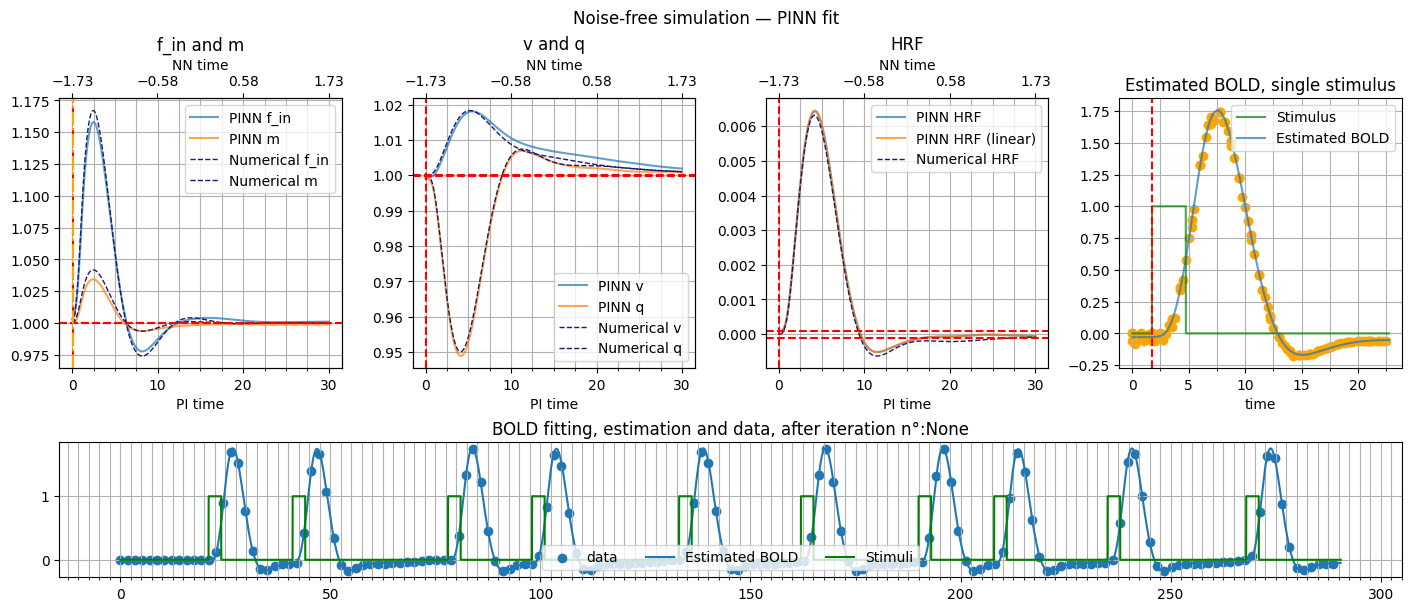

In [10]:
# Build the normalised time axis that train() used internally
t        = torch.arange(0, Impulse.shape[0]) / Impulse.shape[0]
t_nn     = ((t - t.mean()) / t.std()).view(-1, 1)

# Single-trial stimulus (needed for show_bold_signal panel)
time_bf_stim = TR
stimulus, stimulus_time = experimental_stims(
    normDataSize = 13,
    Sti_Onsets   = [time_bf_stim],
    TR           = TR,
    block_len    = sti_len,
    stmxblck     = 1,
)

plot_balloon_fitting(
    model                = model,
    t_normalized         = t_nn,
    domain               = domain,
    stimulus             = stimulus,
    title                = 'Noise-free simulation — PINN fit',
    numerical_solutions  = {'f': f_t, 'm': m_t, 'v': v_t, 'q': q_t, 'bold': num_balloon_hrf},
    data_params          = {
        'TR':               TR,
        'Sti_Onsets':       Sti_Onsets,
        'Bold_Signal':      sampled_bold_test,
        'Bold_data_time':   num_bold_time[::sampling_rate],
        'stim_length [seg]': sti_len,
        'stimulus':          stimulus,
        'stimulus_time':     stimulus_time,
        'Overallstim':       Overall_stims,
        'Overall_stim_time': stim_time,    # ← correct key name
    },
    first_non_zero_index = torch.argmax(Impulse) - 1,
    show_bold_signal     = True,
)

## 8  Loss curves

In [11]:
plot_trace(loss_trace, title='Loss — noise-free simulation', step_size=step_size)

ValueError: Unknown loss key: other

In [12]:
plot_weights(w_raw, title='Adaptive weights — noise-free simulation',
             keys_to_skip=[], step_size=step_size)

ValueError: Unknown key: other

## 9  Quantitative evaluation

In [13]:
import torch

model.eval()
with torch.no_grad():
    _, _ = model(t_nn)
    hrf_pinn = model.predictor()

# Convolve HRF with overall stimulus → BOLD prediction at high resolution
bold_pred, bold_pred_time = tofit(Overall_stims, hrf_pinn, n_samples * TR)

# Subsample to fMRI TR
idx, _ = timeBall(torch.as_tensor(Bold_time), bold_pred_time)
bold_at_TR = tensor2np(bold_pred[idx])

# Kling-Gupta Efficiency (1.0 = perfect)
kge = kge_stat(y_obs=sampled_bold_test, y_sim=bold_at_TR)
print(f'KGE = {kge:.4f}  (1.0 = perfect)')

# HRF shape descriptors
desc = hrf_description(tensor2np(hrf_pinn), max_time=domain[1])
for k, v_d in desc.items():
    print(f'  {k}: {v_d[0]:.4f}')

KGE = 0.8841  (1.0 = perfect)
  HP: 0.0064
  TTP[s]: 4.1700
  FWHM[s]: 4.8000
  TO[s]: 1.0400
  AUC: 0.0310
  MU: -0.0005
  TTU[s]: 11.4000
  TT0[s]: 17.1100


---
## 10  Noise addition (Shan 2014)

We now train the same PINN on a **noisy** simulation to test robustness.  
Noise is added as:  $\hat{TC} = TC + (1 + \sigma) \cdot \epsilon$

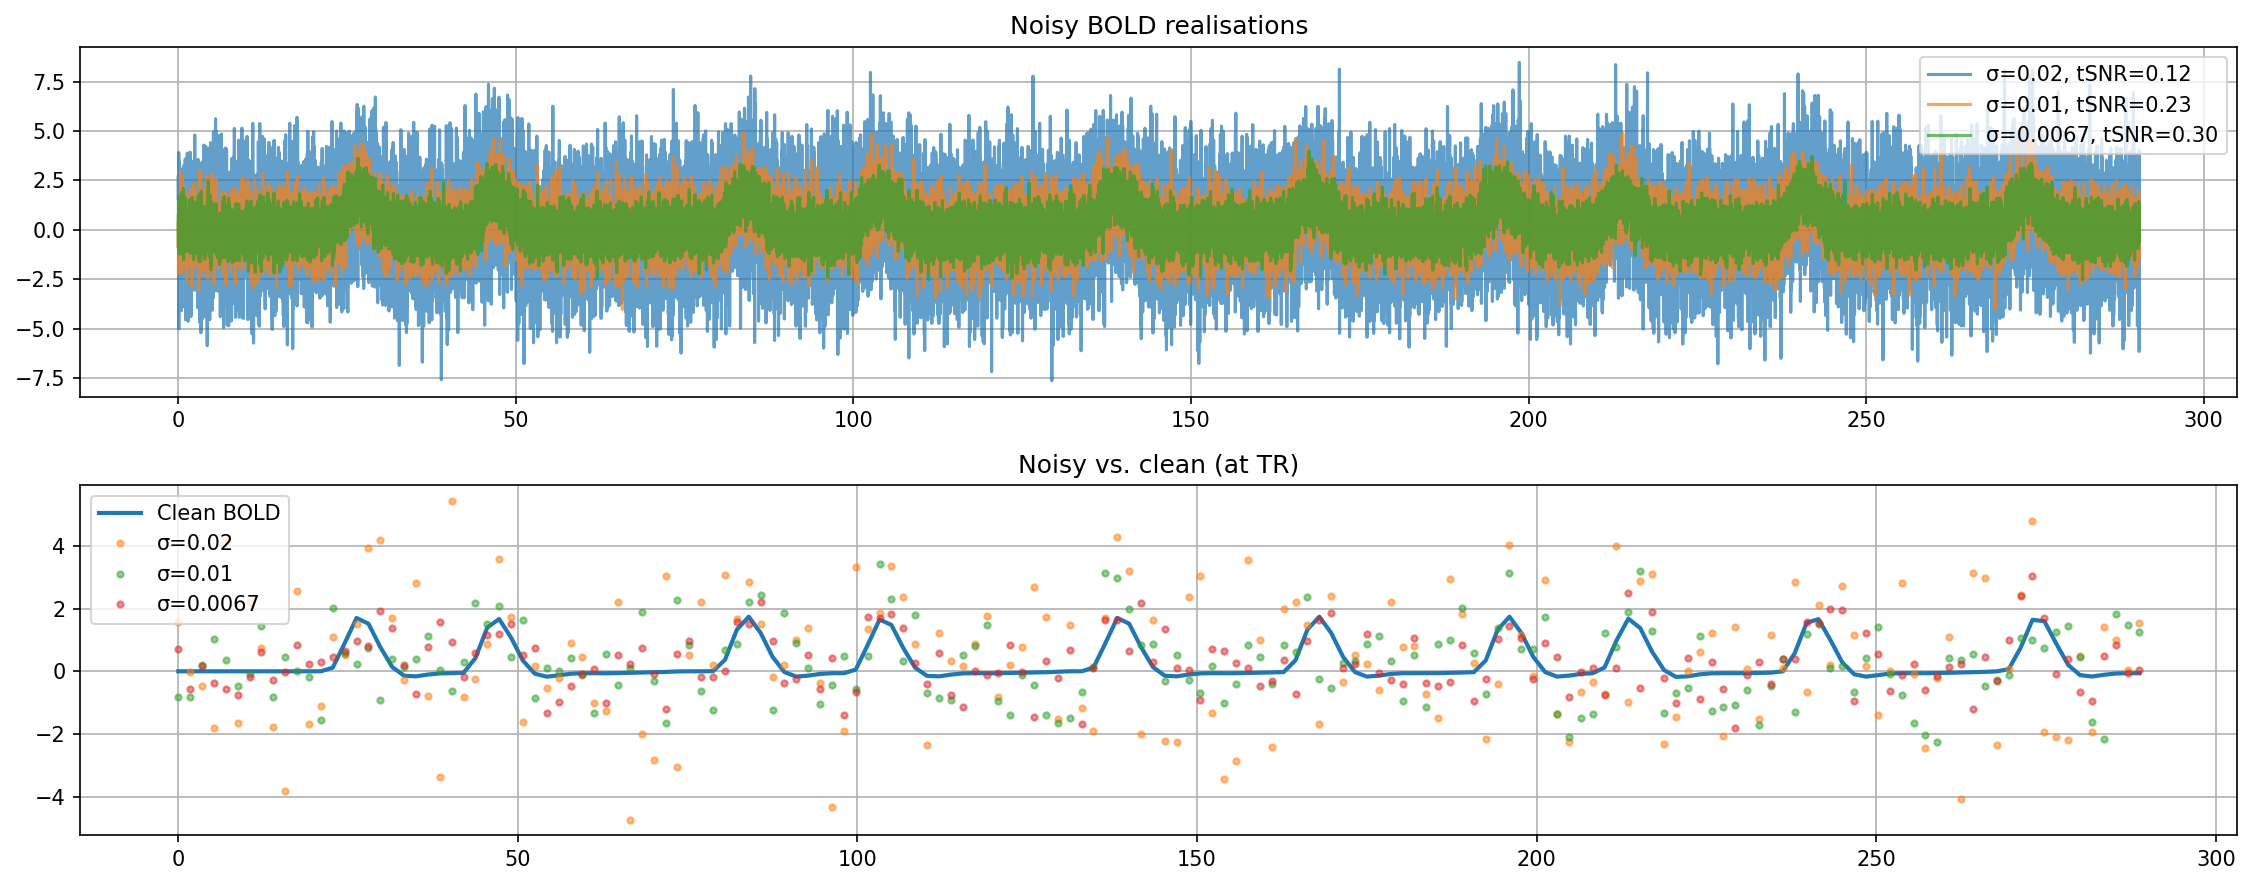

In [14]:
# Generate three noise levels
noise_levels = [0.02, 0.01, 0.0067]
noise_list   = [torch.randn(1, len(num_bold_test)) * s for s in noise_levels]
noise        = torch.cat(noise_list, dim=0)   # shape (3, N)

def adding_noise(TC, noise_tensor):
    n_signals = noise_tensor.shape[0]
    return TC.repeat(n_signals, 1) + 100 * noise_tensor

def tSNR(x):
    ax = int(np.argmax(x.shape))
    return x.mean(axis=ax) / x.std(axis=ax)

tmp       = tensor2np(adding_noise(num_bold_test, noise))
tsnr_vals = list(tSNR(tmp))

norm = lambda x, a: 100 * (x - x.mean(axis=a)) / x.mean(axis=a)

fig, ax = plt.subplots(2, 1, figsize=(15, 6), dpi=150)
labels = [f'σ={s}' for s in noise_levels]
for k, (row, lbl) in enumerate(zip(tmp, labels)):
    ax[0].plot(stim_time_np, row, alpha=0.7, label=f'{lbl}, tSNR={tsnr_vals[k]:.2f}')
ax[0].set_title('Noisy BOLD realisations')
ax[0].legend()
ax[0].grid()

ax[1].plot(Bold_time, sampled_bold_test, label='Clean BOLD', lw=2)
for k, (row, lbl) in enumerate(zip((tmp[:, ::sampling_rate]), labels)):
    ax[1].plot(Bold_time, row, '.', alpha=0.5, label=lbl)
ax[1].set_title('Noisy vs. clean (at TR)')
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

## 11  Train on noisy BOLD (σ = 0.01)

 33%|███▎      | 1658/5000 [00:21<00:42, 78.51it/s]

1666th Iter:
total 1.7470e+00, ode:1.621e-03, bold:1.053e+00, Dic:2.271e-05, Cic:6.653e-05, other:1.021e-03
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1263.3, 'bold': 1.0, 'ic': 1263.3, 'border': 1263.3, 'other': 1263.3}


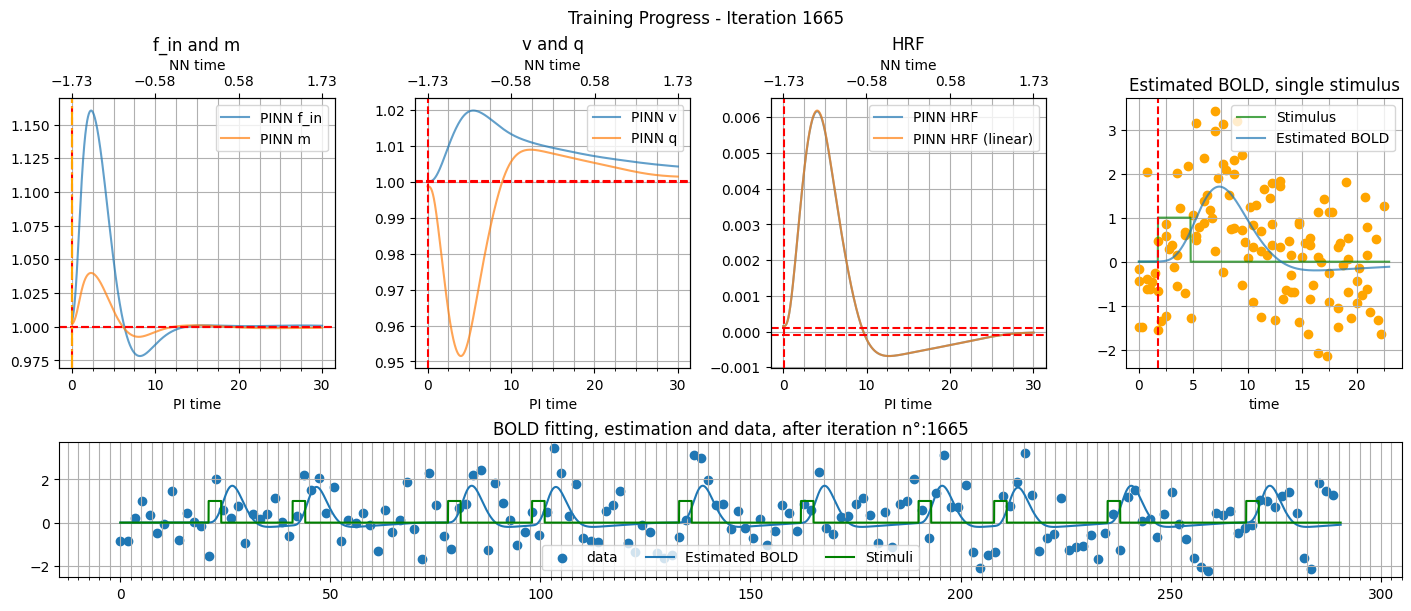

 67%|██████▋   | 3331/5000 [00:44<00:22, 74.71it/s]

3332th Iter:
total 1.7417e+00, ode:1.347e-03, bold:1.055e+00, Dic:2.179e-05, Cic:5.354e-05, other:2.607e-04
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1440.1, 'bold': 1.0, 'ic': 1440.1, 'border': 1440.1, 'other': 1440.1}


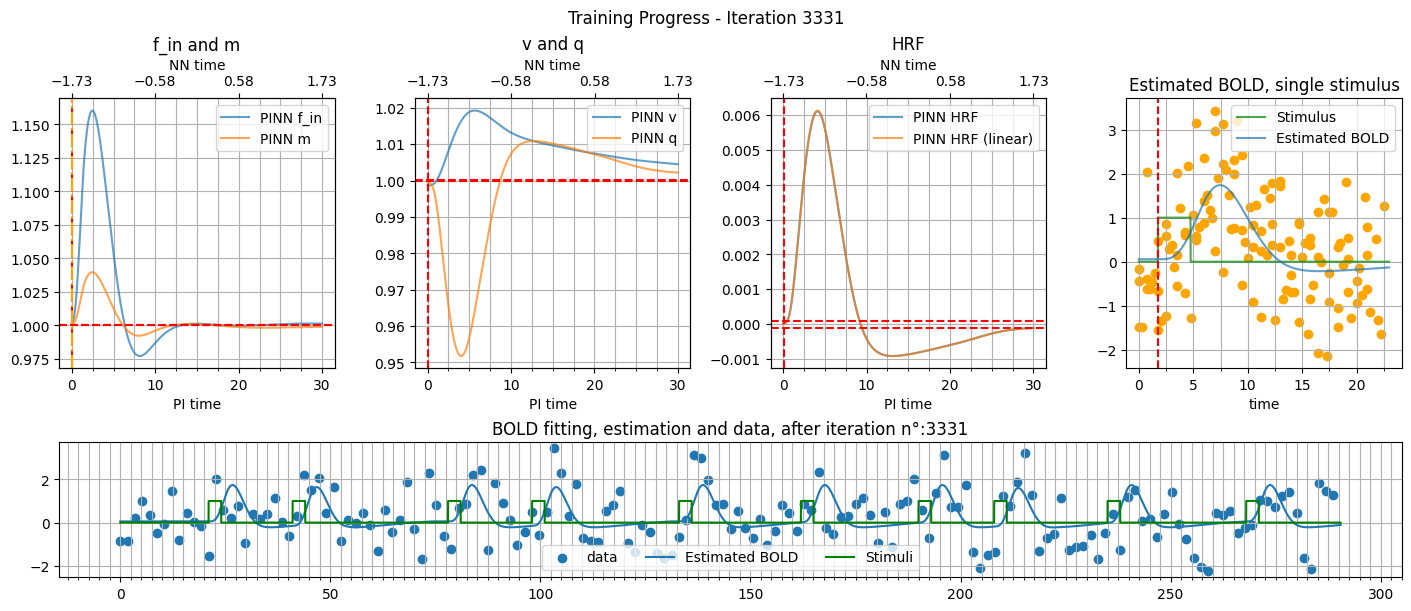

100%|█████████▉| 4997/5000 [01:06<00:00, 76.84it/s]

4998th Iter:
total 1.9095e+00, ode:1.594e-03, bold:1.087e+00, Dic:4.928e-05, Cic:4.181e-05, other:3.310e-04
total weights, ode:6.000e-01, bold:4.000e-01, Dic:1.000e+00, Cic:1.000e+00, other:0.000e+00
Physics amp {'ode': 1403.6, 'bold': 1.0, 'ic': 1403.6, 'border': 1403.6, 'other': 1403.6}


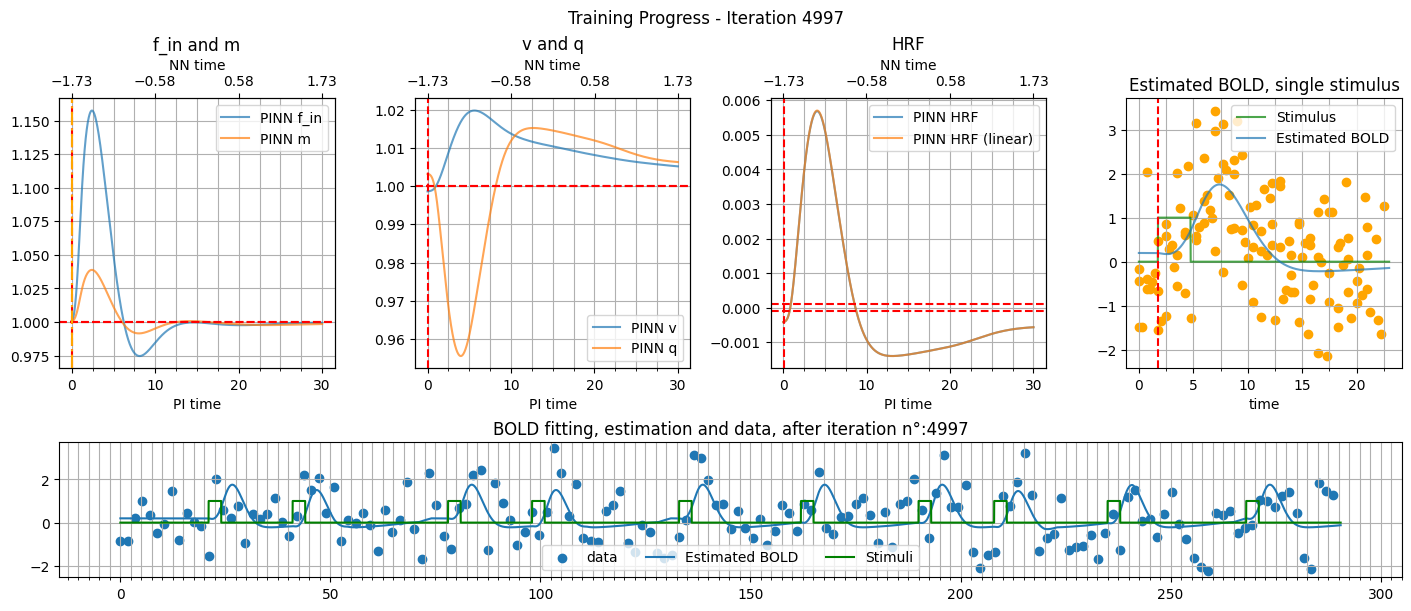

100%|██████████| 5000/5000 [01:06<00:00, 74.69it/s]


In [15]:
# Use the medium-noise realisation (index 1, σ=0.01)
sampled_noise_bold = tmp[1, ::sampling_rate]
tsnr_noisy         = tSNR(tmp[:, ::sampling_rate])[1]

data_dict_noisy = {
    'TR':               TR,
    'Sti_Onsets':       Sti_Onsets,
    'Bold_Signal':      sampled_noise_bold,
    'errorFn':          nn.MSELoss(),
    'stim_length [seg]': sti_len,
    'stim_x_block':     1,
    't0':               0,
}

model_noisy = Multihead(random_weightsMatrix=True, dtype=torch.float32)
model_noisy.init_nn_params()

optimizer_n = optim.Adam(model_noisy.parameters(), lr=learning_rate)
scheduler_n = optim.lr_scheduler.StepLR(optimizer_n, step_size=step_size, gamma=percent)

# Reset weights for noisy run
w_noisy = {k: [v[0]] for k, v in w_raw.items()}

loss_trace_noisy = train(
    model          = model_noisy,
    optimizer      = optimizer_n,
    lossfn         = loss,
    num_iter       = num_iter,
    Balloon_params = Balloon_dict,
    data_params    = data_dict_noisy,
    domain         = domain,
    random         = False,
    every          = every,
    loss_weights   = w_noisy,
    scheduler      = scheduler_n,
    dtype          = torch.float32,
)

## 12  Visualise — noisy fit

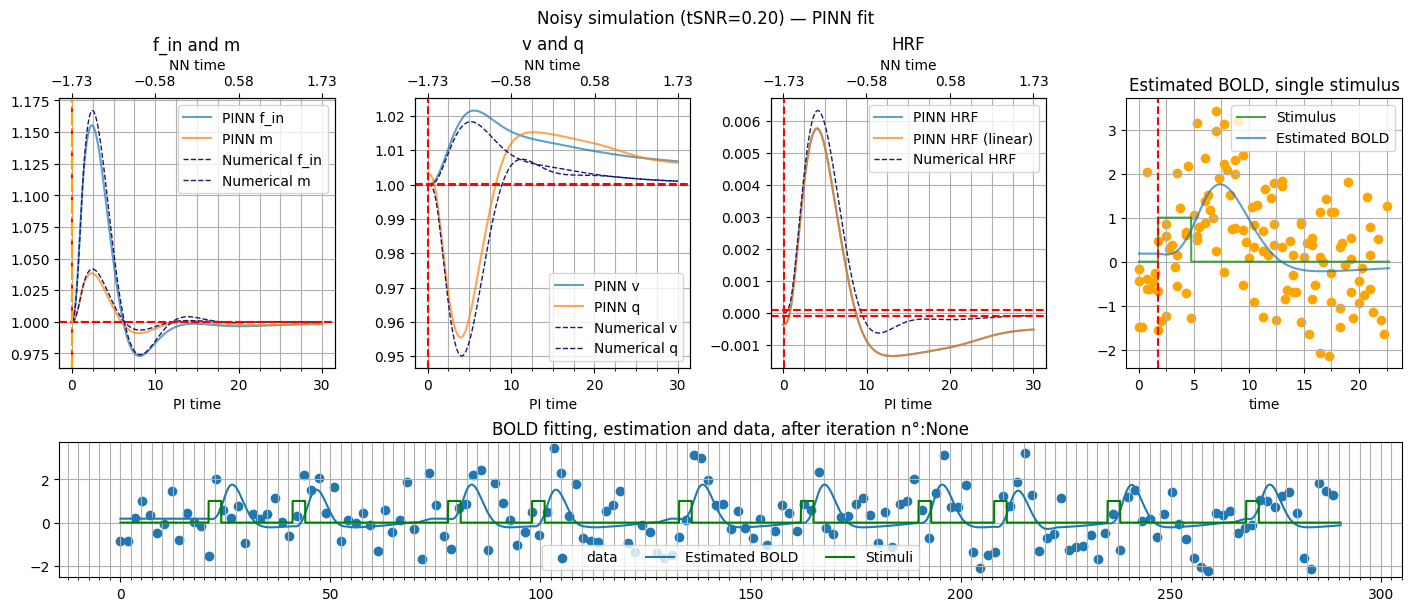

ValueError: Unknown loss key: other

In [17]:
plot_balloon_fitting(
    model                = model_noisy,
    t_normalized         = t_nn,
    domain               = domain,
    stimulus             = stimulus,
    title                = f'Noisy simulation (tSNR={tsnr_noisy:.2f}) — PINN fit',
    numerical_solutions  = {'f': f_t, 'm': m_t, 'v': v_t, 'q': q_t, 'bold': num_balloon_hrf},
    data_params          = {
        'TR':               TR,
        'Sti_Onsets':       Sti_Onsets,
        'Bold_Signal':      sampled_noise_bold,
        'Bold_data_time':   num_bold_time[::sampling_rate],
        'stim_length [seg]': sti_len,
        'stimulus':          stimulus,
        'stimulus_time':     stimulus_time,
        'Overallstim':       Overall_stims,
        'Overall_stim_time': stim_time,
    },
    first_non_zero_index = torch.argmax(Impulse) - 1,
    show_bold_signal     = True,
)

plot_trace(loss_trace_noisy, title=f'Loss — noisy simulation (tSNR={tsnr_noisy:.2f})', step_size=step_size)

## Next steps

- **Real fMRI data**: replace `sampled_bold_test` with your normalised BOLD using `normFn()`
- **Adaptive reweighting**: call `loss_reweight_paranoid()` between training phases
- **Fourier features**: set `use_fourier=True` for improved high-frequency fitting
- **`BalloonExample.ipynb`**: deeper dive into the `balloonmodellib` numerical pipeline